In [3]:
import numpy as np
import os
import matplotlib.pyplot as plt

In [5]:
name = 'hcenterp'
plotspath = f'/home/kale-chen/Documents/PET/TPPT2026/plots/'
#counts = [61856730, 47667618, 46805697]
counts = [31883916, 27428512, 27320277]

numrows = os.path.getsize(os.path.join(plotspath, f'{name}prehistL.bin')) // 8
print(numrows)
prehistL = np.fromfile(os.path.join(plotspath, f'{name}prehistL.bin'), dtype = np.float32).reshape(numrows, 2) 
prehistR = np.fromfile(os.path.join(plotspath, f'{name}prehistR.bin'), dtype = np.float32).reshape(numrows, 2)
posthistL = np.fromfile(os.path.join(plotspath, f'{name}posthistL.bin'), dtype = np.float32).reshape(numrows, 2)
posthistR = np.fromfile(os.path.join(plotspath, f'{name}posthistR.bin'), dtype = np.float32).reshape(numrows, 2)
itimehistL = np.fromfile(os.path.join(plotspath, f'{name}itimehistL.bin'), dtype = np.float32).reshape(numrows, 2)
itimehistR = np.fromfile(os.path.join(plotspath, f'{name}itimehistR.bin'), dtype = np.float32).reshape(numrows, 2)

500


11364.011 10934.125 11363.65 10935.0
480 9
3868.97, 3857.85 3863.41 0.000141


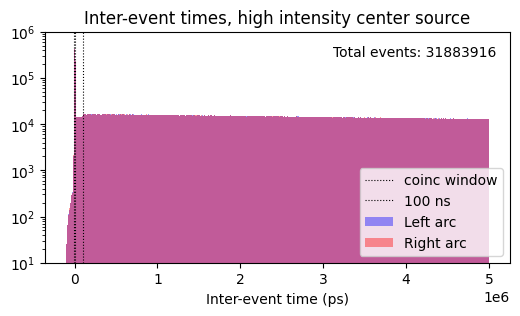

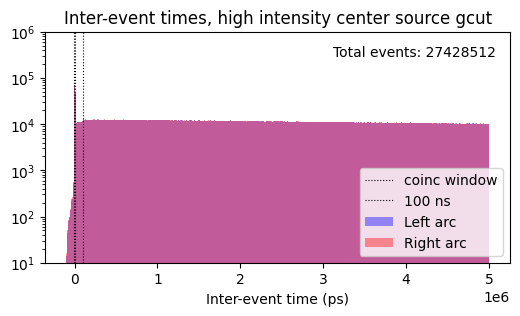

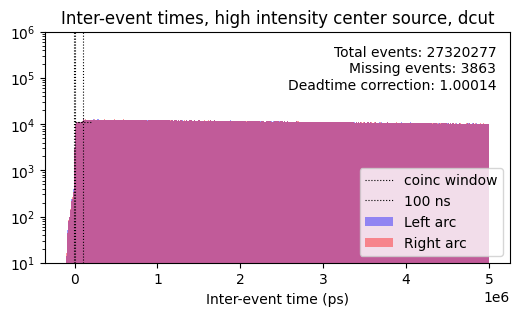

In [8]:
plt.figure(0, figsize = (6, 3))
plt.bar(prehistL[:, 1], prehistL[:, 0], width = prehistL[1, 1] - prehistL[0, 1] + 0.001, color = 'blue', alpha = 0.4, label = 'Left arc')
plt.bar(prehistR[:, 1], prehistR[:, 0], width = prehistR[1, 1] - prehistR[0, 1] + 0.001, color = 'red', alpha = 0.4, label = 'Right arc')
plt.yscale('log')
plt.ylim(1e1, 1e6)
plt.vlines([-10000, 10000], *plt.ylim(), color = 'black', linestyle = 'dotted', linewidth = 0.8, label = 'coinc window')
plt.vlines([100000], *plt.ylim(), color = 'black', linestyle = 'dotted', linewidth = 0.8, label = '100 ns')
plt.xlabel('Inter-event time (ps)')
plt.legend(loc = 'lower right')
text = f'Total events: {counts[0]}'
plt.text(0.97, 0.94, text, color='black', fontsize=10, ha='right', va='top',
        transform=plt.gca().transAxes)
plt.title(f'Inter-event times, high intensity center source')
plt.ticklabel_format(
    axis='x',
    style='sci',
    scilimits=(0, 0),
    useMathText=False
)
plt.figure(1, figsize = (6, 3))
plt.bar(posthistL[:, 1], posthistL[:, 0], width = posthistL[1, 1] - posthistL[0, 1] + 0.001, color = 'blue', alpha = 0.4, label = 'Left arc')
plt.bar(posthistR[:, 1], posthistR[:, 0], width = posthistR[1, 1] - posthistR[0, 1] + 0.001, color = 'red', alpha = 0.4, label = 'Right arc')
plt.yscale('log')
plt.ylim(1e1, 1e6)
plt.vlines([-10000, 10000], *plt.ylim(), color = 'black', linestyle = 'dotted', linewidth = 0.8, label = 'coinc window')
plt.vlines([100000], *plt.ylim(), color = 'black', linestyle = 'dotted', linewidth = 0.8, label = '100 ns')
plt.xlabel('Inter-event time (ps)')
plt.legend(loc = 'lower right')
text = f'Total events: {counts[1]}'
plt.text(0.97, 0.94, text, color='black', fontsize=10, ha='right', va='top',
        transform=plt.gca().transAxes)
plt.title(f'Inter-event times, high intensity center source gcut')
plt.figure(2, figsize = (6, 3))
meantrueL = np.mean(itimehistL[:, 0][itimehistL[:, 1] > 105000])
meandeadL = np.mean(itimehistL[:, 0][(itimehistL[:, 1] < 95000) & (itimehistL[:, 1] > 15000)])
meantrueR = np.mean(itimehistR[:, 0][itimehistR[:, 1] > 105000])
meandeadR = np.mean(itimehistR[:, 0][(itimehistR[:, 1] < 95000) & (itimehistR[:, 1] > 15000)])
print(meantrueL, meandeadL, meantrueR, meandeadR)
masktrue = itimehistL[:, 1] > 100000
maskdead = (itimehistL[:, 1] < 100000) & (itimehistL[:, 1] > 10000)
print(np.sum(masktrue), np.sum(maskdead))
correctionL = (meantrueL - meandeadL) * np.sum(maskdead)
correctionR = (meantrueR - meandeadR) * np.sum(maskdead)
print(f'{correctionL:.2f}, {correctionR:.2f}', f'{(correctionL + correctionR) / 2:.2f}', f'{(correctionL + correctionR) / (2*counts[2]):.6f}')
plt.bar(itimehistL[:, 1], itimehistL[:, 0], width = itimehistL[1, 1] - itimehistL[0, 1] + 0.001, color = 'blue', alpha = 0.4, label = 'Left arc')
plt.bar(itimehistR[:, 1], itimehistR[:, 0], width = itimehistR[1, 1] - itimehistR[0, 1] + 0.001, color = 'red', alpha = 0.4, label = 'Right arc')
plt.yscale('log')
plt.ylim(1e1, 1e6)
plt.vlines([-10000, 10000], *plt.ylim(), color = 'black', linestyle = 'dotted', linewidth = 0.8, label = 'coinc window')
plt.vlines([100000], *plt.ylim(), color = 'black', linestyle = 'dotted', linewidth = 0.8, label = '100 ns')
plt.hlines((meantrueL + meantrueR) / 2, 10000, 200000, color = 'black', linestyle = 'dotted', linewidth = 0.8)
plt.hlines((meandeadL + meandeadR) / 2, 10000, 100000, color = 'black', linestyle = 'dotted', linewidth = 0.8)
plt.xlabel('Inter-event time (ps)')
plt.legend(loc = 'lower right')
deadtimecorrection = (counts[2] + (correctionL + correctionR) / 2) / counts[2]
text = f'Total events: {counts[2]}\nMissing events: {(correctionL + correctionR) / 2:.0f}\nDeadtime correction: {deadtimecorrection:.5f}'
plt.text(0.97, 0.94, text, color='black', fontsize=10, ha='right', va='top',
        transform=plt.gca().transAxes)
plt.title(f'Inter-event times, high intensity center source, dcut')
plt.show()

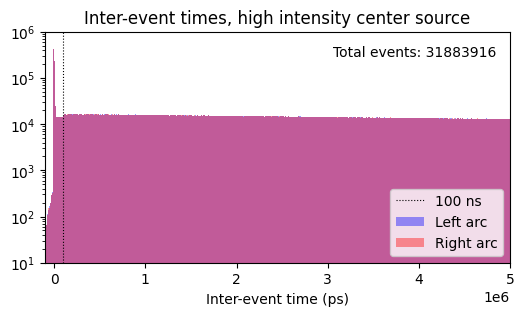

In [6]:
# Custom plotting 
bins = np.linspace(-100000, 5000000, 501)
bincenters = bins[:-1] + (bins[1] - bins[0]) / 2
plt.figure(0, figsize = (6,3))
plt.bar(prehistL[:, 1], prehistL[:, 0], width = prehistL[1, 1] - prehistL[0, 1], color = 'blue', alpha = 0.4, label = 'Left arc')
plt.bar(prehistR[:, 1], prehistR[:, 0], width = prehistR[1, 1] - prehistR[0, 1], color = 'red', alpha = 0.4, label = 'Right arc')
plt.yscale('log')
plt.ylim(1e1, 1e6)
#plt.vlines([-10000, 10000], *plt.ylim(), color = 'black', linestyle = 'dotted', linewidth = 0.8, label = 'coinc window')
plt.vlines([100000], *plt.ylim(), color = 'black', linestyle = 'dotted', linewidth = 0.8, label = '100 ns')
plt.xlabel('Inter-event time (ps)')
plt.legend(loc = 'lower right')
text = f'Total events: {counts[0]}'
plt.text(0.97, 0.94, text, color='black', fontsize=10, ha='right', va='top',
        transform=plt.gca().transAxes)
plt.title(f'Inter-event times, high intensity center source')
plt.xlim(-100000, 5000000)
plt.savefig('/home/kale-chen/Documents/PET/TPPT2026/plots/hcenteritimesbig.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

1529.8875 1342.3055 1529.3375 1342.4445
80 72
13505.90, 13456.30 13481.10 0.000493


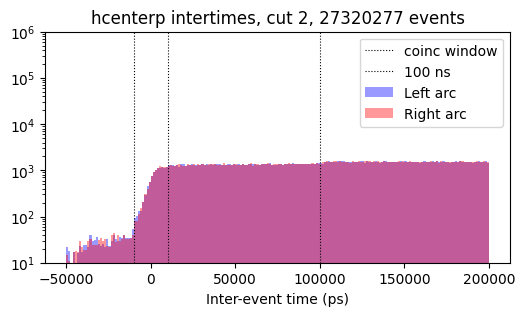

In [58]:
meantrueL = np.mean(itimehistL[:, 0][itimehistL[:, 1] > 100000])
meandeadL = np.mean(itimehistL[:, 0][(itimehistL[:, 1] < 100000) & (itimehistL[:, 1] > 10000)])
meantrueR = np.mean(itimehistR[:, 0][itimehistR[:, 1] > 100000])
meandeadR = np.mean(itimehistR[:, 0][(itimehistR[:, 1] < 100000) & (itimehistR[:, 1] > 10000)])
print(meantrueL, meandeadL, meantrueR, meandeadR)
masktrue = itimehistL[:, 1] > 100000
maskdead = (itimehistL[:, 1] < 100000) & (itimehistL[:, 1] > 10000)
print(np.sum(masktrue), np.sum(maskdead))
correctionL = (meantrueL - meandeadL) * np.sum(maskdead)
correctionR = (meantrueR - meandeadR) * np.sum(maskdead)
print(f'{correctionL:.2f}, {correctionR:.2f}', f'{(correctionL + correctionR) / 2:.2f}', f'{(correctionL + correctionR) / (2*counts[2]):.6f}')



plt.figure(0, figsize = (6, 3))
plt.bar(itimehistL[:, 1], itimehistL[:, 0], width = itimehistL[1, 1] - itimehistL[0, 1] + 0.001, color = 'blue', alpha = 0.4, label = 'Left arc')
plt.bar(itimehistR[:, 1], itimehistR[:, 0], width = itimehistR[1, 1] - itimehistR[0, 1] + 0.001, color = 'red', alpha = 0.4, label = 'Right arc')
plt.yscale('log')
plt.ylim(1e1, 1e6)
plt.vlines([-10000, 10000], *plt.ylim(), color = 'black', linestyle = 'dotted', linewidth = 0.8, label = 'coinc window')
plt.vlines([100000], *plt.ylim(), color = 'black', linestyle = 'dotted', linewidth = 0.8, label = '100 ns')
plt.xlabel('Inter-event time (ps)')
plt.title(f'{name} intertimes, cut 2, {counts[2]} events')
plt.legend()
plt.show()